In [1]:
import pandas as pd

# Load dataset

file_path = '../data/raw/synthetic_employability_data.csv'

df = pd.read_csv(file_path)

# View data
df.head()

,Age,Gender_Male,Gender_Female,Edu_Level,Field_IT,Field_Business,Field_Engineering,Field_Vocational,Field_Arts,Field_Science,Field_General,Skill_Analytical,Skill_Resilience,Skill_Leadership,Skill_Creative,Skill_Motivation,Skill_Tech_Literacy,Skill_Empathy,Skill_Curiosity,Target_Employed
0,24,0,1,2,1,0,0,0,0,0,0,4,1,2,5,2,4,2,1,0
1,21,1,0,4,0,0,0,0,0,1,0,1,5,3,4,4,3,1,1,1
2,28,1,0,6,0,1,0,0,0,0,0,2,5,5,5,2,5,3,2,1
3,25,1,0,3,0,0,0,1,0,0,0,3,2,5,3,3,3,2,4,1
4,22,0,1,1,0,0,0,0,0,1,0,5,3,4,5,5,3,3,2,1


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  1500 non-null   int64
 1   Gender_Male          1500 non-null   int64
 2   Gender_Female        1500 non-null   int64
 3   Edu_Level            1500 non-null   int64
 4   Field_IT             1500 non-null   int64
 5   Field_Business       1500 non-null   int64
 6   Field_Engineering    1500 non-null   int64
 7   Field_Vocational     1500 non-null   int64
 8   Field_Arts           1500 non-null   int64
 9   Field_Science        1500 non-null   int64
 10  Field_General        1500 non-null   int64
 11  Skill_Analytical     1500 non-null   int64
 12  Skill_Resilience     1500 non-null   int64
 13  Skill_Leadership     1500 non-null   int64
 14  Skill_Creative       1500 non-null   int64
 15  Skill_Motivation     1500 non-null   int64
 16  Skill_Tech_Literacy  1500 non-null 

,Age,Gender_Male,Gender_Female,Edu_Level,Field_IT,Field_Business,Field_Engineering,Field_Vocational,Field_Arts,Field_Science,Field_General,Skill_Analytical,Skill_Resilience,Skill_Leadership,Skill_Creative,Skill_Motivation,Skill_Tech_Literacy,Skill_Empathy,Skill_Curiosity,Target_Employed
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.0000,1500.00000
mean,23.399333,0.534667,0.465333,3.480667,0.127333,0.137333,0.138000,0.154000,0.138000,0.150667,0.154667,3.027333,2.981333,3.018000,2.93000,3.004000,2.958667,2.962000,3.0540,0.45000
std,3.480605,0.498963,0.498963,1.713744,0.333457,0.344314,0.345015,0.361069,0.345015,0.357843,0.361707,1.423120,1.413146,1.438653,1.39322,1.417035,1.416438,1.442894,1.4186,0.49766
min,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.0000,0.00000
25%,20.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.0000,0.00000
50%,23.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.0000,0.00000
75%,26.000000,1.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.0000,1.00000
max,29.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.0000,1.00000


In [3]:
# Check the raw counts
print("Class Counts:")
print(df['Target_Employed'].value_counts())

# Check the percentages
print("\nClass Percentages:")
print(df['Target_Employed'].value_counts(normalize=True) * 100)

Class Counts:
Target_Employed
0    825
1    675
Name: count, dtype: int64

Class Percentages:
Target_Employed
0    55.0
1    45.0
Name: proportion, dtype: float64


In [4]:
df.isnull().sum()
df = df.dropna()

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
X = df.drop("Target_Employed", axis=1)
y = df["Target_Employed"]

In [8]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ==============================
# DEFINE MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ==============================
# TRAIN & EVALUATE
# ==============================
results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })
    
    # Print results
    print(f"{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

# ==============================
# RESULTS TABLE
# ==============================
results_df = pd.DataFrame(results)
results_df


Logistic Regression
Accuracy: 0.8100
Precision: 0.8067
Recall: 0.7385
F1 Score: 0.7711
----------------------------------------
Decision Tree
Accuracy: 0.8333
Precision: 0.7632
Recall: 0.8923
F1 Score: 0.8227
----------------------------------------
Random Forest
Accuracy: 0.8800
Precision: 0.8730
Recall: 0.8462
F1 Score: 0.8594
----------------------------------------


C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:39:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Accuracy: 0.8933
Precision: 0.8769
Recall: 0.8769
F1 Score: 0.8769
----------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8100,0.8067,0.7385,0.7711
1,Decision Tree,0.8333,0.7632,0.8923,0.8227
2,Random Forest,0.8800,0.8730,0.8462,0.8594
3,XGBoost,0.8933,0.8769,0.8769,0.8769


In [10]:
# Select best model based on F1 Score
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [11]:
best_model = models[best_model_name]

# Retrain on full training data
best_model.fit(X_train, y_train)

C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
#### Probability Calibration & Evaluation

C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:39:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:39:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:39:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\SLIIT\Y4S1\Research Project\Project\employability_framework\venv\Lib\site-packages\xgboost\traini

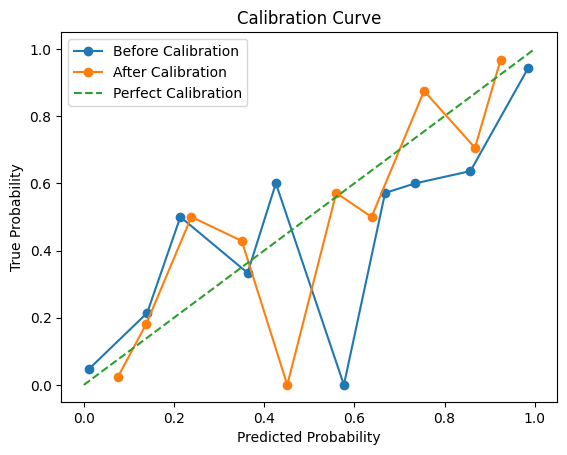

Brier Score (Before): 0.0818
Brier Score (After): 0.0782
Log Loss (Before): 0.2882
Log Loss (After): 0.2744


,Metric,Before Calibration,After Calibration
0,Brier Score,0.081785,0.078231
1,Log Loss,0.288199,0.274368


In [13]:
# Calibrate the Model
from sklearn.calibration import CalibratedClassifierCV

# Calibrate (Platt scaling)
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)

calibrated_model.fit(X_train, y_train)

# Compare Probabilities (Before vs After)
# Before calibration
y_prob_before = best_model.predict_proba(X_test)[:, 1]

# After calibration
y_prob_after = calibrated_model.predict_proba(X_test)[:, 1]

# Calibration Curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_before, prob_pred_before = calibration_curve(y_test, y_prob_before, n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_test, y_prob_after, n_bins=10)

plt.figure()

# Before calibration
plt.plot(prob_pred_before, prob_true_before, marker='o', label='Before Calibration')

# After calibration
plt.plot(prob_pred_after, prob_true_after, marker='o', label='After Calibration')

# Perfect calibration line
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# Brier Score
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(y_test, y_prob_before)
brier_after = brier_score_loss(y_test, y_prob_after)

print("Brier Score (Before):", round(brier_before, 4))
print("Brier Score (After):", round(brier_after, 4))

# Log Loss
from sklearn.metrics import log_loss

logloss_before = log_loss(y_test, y_prob_before)
logloss_after = log_loss(y_test, y_prob_after)

print("Log Loss (Before):", round(logloss_before, 4))
print("Log Loss (After):", round(logloss_after, 4))

# results
import pandas as pd

calibration_results = pd.DataFrame({
    "Metric": ["Brier Score", "Log Loss"],
    "Before Calibration": [brier_before, logloss_before],
    "After Calibration": [brier_after, logloss_after]
})

calibration_results

In [14]:
####### SHAP

In [14]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

In [15]:
print(type(explainer.expected_value))
print(explainer.expected_value)

print(shap_values.values.shape)

<class 'numpy.float32'>
-0.24049735
(300, 19)


In [16]:
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values.values[i],       
    X_test.iloc[i]
)

In [17]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


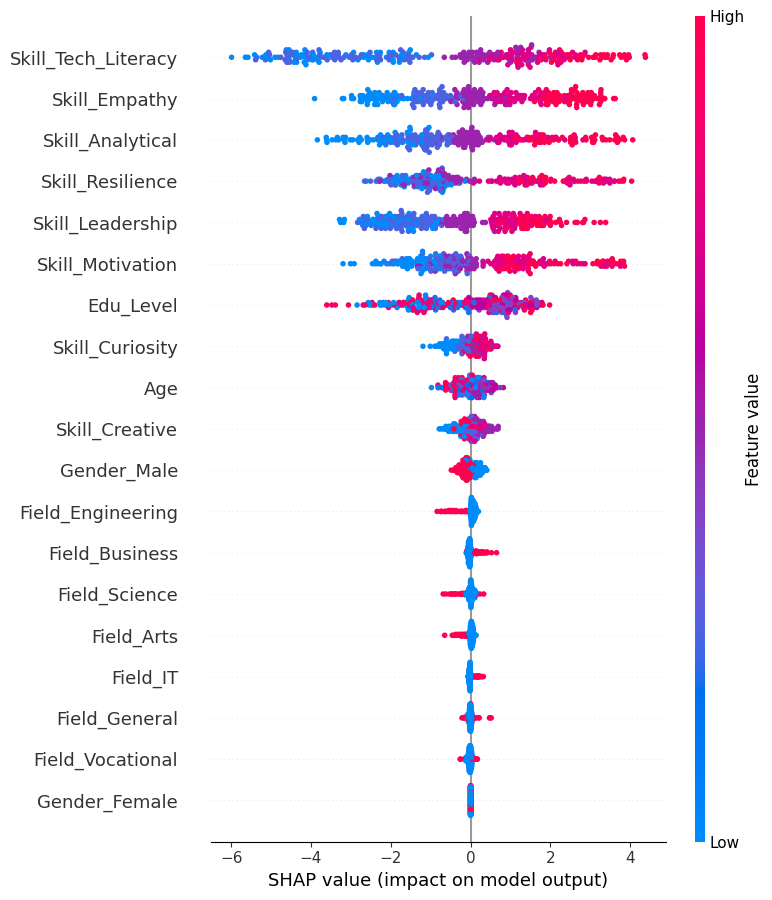

In [18]:
shap.summary_plot(shap_values.values, X_test)

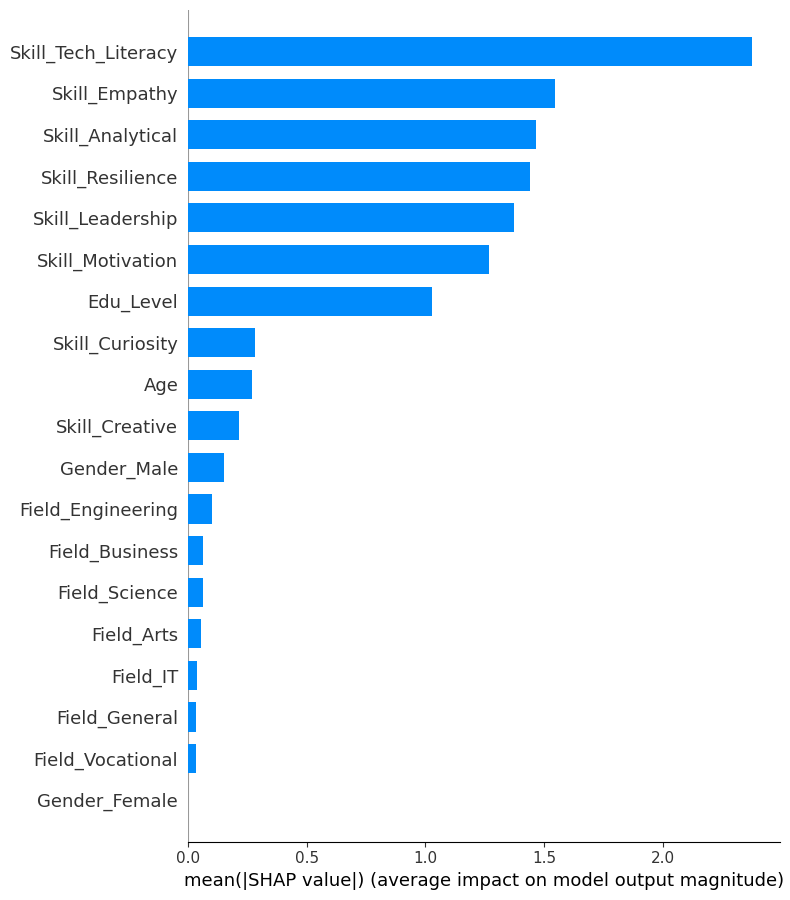

In [19]:
shap.summary_plot(shap_values.values, X_test, plot_type="bar")

In [20]:
########  Counterfactual Recommendations (DiCE)

In [21]:
import dice_ml
from dice_ml import Dice

In [22]:
# ==============================
# STEP — Prepare Data for DiCE
# ==============================

# Combine features + target
df_dice = X.copy()
df_dice["Target_Employed"] = y

# All features treated as continuous
continuous_features = X.columns.tolist()

# Create DiCE Data Object
data_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_features,
    outcome_name="Target_Employed"
)

# ==============================
# STEP — Wrap Model
# ==============================
model_dice = dice_ml.Model(
    model=calibrated_model,   # calibrated model
    backend="sklearn"
)

# Create Explainer
exp = Dice(data_dice, model_dice)

# ==============================
# STEP — Select NON-EMPLOYABLE user
# ==============================
i = None

for idx in range(len(X_test)):
    pred = calibrated_model.predict(X_test.iloc[[idx]])[0]
    if pred == 0:
        i = idx
        break

if i is None:
    print("No non-employable user found.")
else:
    query_instance = X_test.iloc[[i]]

    print("Selected User Index:", i)
    print("Prediction:", calibrated_model.predict(query_instance)[0])

    # ==============================
    # STEP — Define Skill Constraints (IMPORTANT)
    # ==============================
    original = query_instance.reset_index(drop=True)

    permitted_range = {
        "Skill_Analytical": [original.iloc[0]["Skill_Analytical"], 5],
        "Skill_Resilience": [original.iloc[0]["Skill_Resilience"], 5],
        "Skill_Leadership": [original.iloc[0]["Skill_Leadership"], 5],
        "Skill_Creative": [original.iloc[0]["Skill_Creative"], 5],
        "Skill_Motivation": [original.iloc[0]["Skill_Motivation"], 5],
        "Skill_Tech_Literacy": [original.iloc[0]["Skill_Tech_Literacy"], 5],
        "Skill_Empathy": [original.iloc[0]["Skill_Empathy"], 5],
        "Skill_Curiosity": [original.iloc[0]["Skill_Curiosity"], 5]
    }

    # ==============================
    # STEP — Generate Counterfactuals
    # ==============================
    cf = exp.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=list(permitted_range.keys()),
        permitted_range=permitted_range,
        random_seed=42 
    )

    # Show table
    cf.visualize_as_dataframe()

    # ==============================
    # STEP — Convert to Recommendations
    # ==============================
    cf_df = cf.cf_examples_list[0].final_cfs_df

    skill_map = {
        "Skill_Analytical": "Analytical thinking",
        "Skill_Resilience": "Resilience",	
        "Skill_Leadership": "Leadership and social influence",	
        "Skill_Creative": "Creative thinking", 
        "Skill_Motivation": "Motivation and self-awareness", 
        "Skill_Tech_Literacy": "Technological literacy", 
        "Skill_Empathy": "Empathy and active listening", 
        "Skill_Curiosity": "Curiosity and lifelong learning"
    }

    recommendations = []

    for col in permitted_range.keys():
        old = original.iloc[0][col]
        new = cf_df.iloc[0][col]

        # ✅ ONLY allow improvements
        if new > old:
            skill_name = skill_map.get(col, col)
            recommendations.append(
                f"Improve {skill_name} from level {int(old)} to level {int(new)}"
            )

    print("\n--- Human Readable Recommendations ---\n")

    if recommendations:
        for rec in recommendations:
            print("-", rec)
    else:
        print("No clear single-skill improvement found. Try improving multiple skills gradually.")

Selected User Index: 0
Prediction: 0


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.13it/s]

Query instance (original outcome : 0)


,Age,Gender_Male,Gender_Female,Edu_Level,Field_IT,Field_Business,Field_Engineering,Field_Vocational,Field_Arts,Field_Science,Field_General,Skill_Analytical,Skill_Resilience,Skill_Leadership,Skill_Creative,Skill_Motivation,Skill_Tech_Literacy,Skill_Empathy,Skill_Curiosity,Target_Employed
0,26,1,0,6,0,0,0,0,0,1,0,5,1,2,5,3,2,1,4,0



Diverse Counterfactual set (new outcome: 1)


,Age,Gender_Male,Gender_Female,Edu_Level,Field_IT,Field_Business,Field_Engineering,Field_Vocational,Field_Arts,Field_Science,Field_General,Skill_Analytical,Skill_Resilience,Skill_Leadership,Skill_Creative,Skill_Motivation,Skill_Tech_Literacy,Skill_Empathy,Skill_Curiosity,Target_Employed
0,26,1,0,6,0,0,0,0,0,1,0,5,1,2,5,3,5,5,4,1
1,26,1,0,6,0,0,0,0,0,1,0,5,1,2,5,3,3,3,4,1
2,26,1,0,6,0,0,0,0,0,1,0,5,1,2,5,3,4,1,4,1



--- Human Readable Recommendations ---

- Improve Technological literacy from level 2 to level 5
- Improve Empathy and active listening from level 1 to level 5


In [23]:
# ==============================
# STEP 1 — Select a sample user
# ==============================
query_instance = X_test.iloc[[0]]   # you can change index

# Convert to input_df
input_df = query_instance.copy()

# ==============================
# STEP 2 — Predict
# ==============================
prediction = calibrated_model.predict(input_df)[0]

# ==============================
# STEP 3 — Generate Counterfactuals (ONLY if needed)
# ==============================
if prediction == 0:

    # Define constraints (IMPORTANT)
    original = input_df.reset_index(drop=True)

    permitted_range = {
        "Skill_Analytical": [original.iloc[0]["Skill_Analytical"], 5],
        "Skill_Resilience": [original.iloc[0]["Skill_Resilience"], 5],
        "Skill_Leadership": [original.iloc[0]["Skill_Leadership"], 5],
        "Skill_Creative": [original.iloc[0]["Skill_Creative"], 5],
        "Skill_Motivation": [original.iloc[0]["Skill_Motivation"], 5],
        "Skill_Tech_Literacy": [original.iloc[0]["Skill_Tech_Literacy"], 5],
        "Skill_Empathy": [original.iloc[0]["Skill_Empathy"], 5],
        "Skill_Curiosity": [original.iloc[0]["Skill_Curiosity"], 5]
    }

    # Generate counterfactuals
    cf = exp.generate_counterfactuals(
        input_df,
        total_CFs=1,
        desired_class="opposite",
        features_to_vary=list(permitted_range.keys()),
        permitted_range=permitted_range,
        random_seed=42 
    )

    # Extract data
    cf_df = cf.cf_examples_list[0].final_cfs_df

    # ==============================
    # STEP 4 — Convert to recommendations
    # ==============================
    skill_map = {
        "Skill_Analytical": "Analytical thinking",
        "Skill_Resilience": "Resilience",	
        "Skill_Leadership": "Leadership and social influence",	
        "Skill_Creative": "Creative thinking", 
        "Skill_Motivation": "Motivation and self-awareness", 
        "Skill_Tech_Literacy": "Technological literacy", 
        "Skill_Empathy": "Empathy and active listening", 
        "Skill_Curiosity": "Curiosity and lifelong learning"
    }

    recommendations = []

    for col in permitted_range.keys():
        old = original.iloc[0][col]
        new = cf_df.iloc[0][col]

        # ✅ ONLY improvements
        if new > old:
            skill_name = skill_map.get(col, col)
            recommendations.append(
                f"Improve {skill_name} from level {int(old)} to level {int(new)}"
            )

    # ==============================
    # STEP 5 — Final Output
    # ==============================
    if recommendations:
        final_text = "To improve employability, you should:\n\n" + "\n".join(recommendations)
    else:
        final_text = (
            "No single-skill improvement identified.\n"
            "Try improving multiple skills gradually."
        )

else:
    final_text = (
        "You are already employable.\n\n"
        "To further strengthen your profile:\n"
        "- Continue improving your core skills\n"
        "- Focus on consistency and real-world application\n"
        "- Stay updated with industry trends"
    )

# ==============================
# OUTPUT
# ==============================
print("Prediction:", "Employable" if prediction == 1 else "Not Employable")
print("\n" + final_text)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.48it/s]

Prediction: Not Employable

To improve employability, you should:

Improve Technological literacy from level 2 to level 5
Improve Empathy and active listening from level 1 to level 5


In [24]:
###### analyze_user(input_data)

In [25]:
feature_columns = X.columns.tolist()

def analyze_user(input_dict):
    import pandas as pd

    # -----------------------------
    # Skill Mapping (DEFINE FIRST)
    # -----------------------------
    skill_map = {
        "Skill_Analytical": "Analytical thinking",
        "Skill_Resilience": "Resilience",	
        "Skill_Leadership": "Leadership and social influence",	
        "Skill_Creative": "Creative thinking", 
        "Skill_Motivation": "Motivation and self-awareness", 
        "Skill_Tech_Literacy": "Technological literacy", 
        "Skill_Empathy": "Empathy and active listening", 
        "Skill_Curiosity": "Curiosity and lifelong learning"
    }

    # -----------------------------
    # Convert input to DataFrame
    # -----------------------------
    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # -----------------------------
    # Prediction (Calibrated Model)
    # -----------------------------
    prediction = calibrated_model.predict(input_df)[0]
    probability = calibrated_model.predict_proba(input_df)[0][1]

    # -----------------------------
    # Message 
    # -----------------------------
    if prediction == 0:
        message = "You are currently not employable, but you can improve by following below recommendations."
    else:
        message = "You are employable."

    # -----------------------------
    # SHAP Explanation
    # -----------------------------
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(input_df)

    shap_dict = dict(zip(feature_columns, shap_values.values[0]))

    top_features = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

    top_factors_readable = []

    for feature, value in top_features:
        name = skill_map.get(feature, feature)

        # CASE 1: Employable → show only positive contributors
        if prediction == 1 and value > 0:
            top_factors_readable.append(f"{name} (increases employability)")

        # CASE 2: Not Employable → show only negative contributors
        elif prediction == 0 and value < 0:
            top_factors_readable.append(f"{name} (decreases employability)")
            
    
    # -----------------------------
    # Counterfactuals
    # -----------------------------
    recommendations = []

    if prediction == 0:
        original = input_df.reset_index(drop=True)
        permitted_range = {
            "Skill_Analytical": [original.iloc[0]["Skill_Analytical"], 5],
            "Skill_Resilience": [original.iloc[0]["Skill_Resilience"], 5],
            "Skill_Leadership": [original.iloc[0]["Skill_Leadership"], 5],
            "Skill_Creative": [original.iloc[0]["Skill_Creative"], 5],
            "Skill_Motivation": [original.iloc[0]["Skill_Motivation"], 5],
            "Skill_Tech_Literacy": [original.iloc[0]["Skill_Tech_Literacy"], 5],
            "Skill_Empathy": [original.iloc[0]["Skill_Empathy"], 5],
            "Skill_Curiosity": [original.iloc[0]["Skill_Curiosity"], 5]
        }
        cf = exp.generate_counterfactuals(
            input_df,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=list(permitted_range.keys()),
            permitted_range=permitted_range,      # ← constrains DiCE to only go upward
            random_seed=42 
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        for col in permitted_range.keys():
            old = original.iloc[0][col]
            new = cf_df.iloc[0][col]
            if new > old:                          # ← only improvements, not just any change
                name = skill_map.get(col, col)
                recommendations.append(
                    f"Improve {name} from level {int(old)} to level {int(new)}"
                )
    else:
        recommendations.append(
            "You are already employable. Continue improving your skills to increase career opportunities."
        )

    # -----------------------------
    # Final Output
    # -----------------------------
    result = {
        "Prediction": "Employable" if prediction == 1 else "Not Employable",
        "Employability Probability Score": f"{float(probability)*100:.2f}%",
        "Message": message,
        "Key Factors Influencing Your Results": top_factors_readable,
        "How to Improve Your Employability Score": recommendations
    }

    return result

In [26]:
sample_user = {
    "age": 23,
    "gender_Male": 1,
    "Edu_Level": 4,
    "Field_Business": 2,
    "Skill_Analytical": 2,
    "Skill_Resilience": 1,
    "Skill_Leadership": 4,
    "Skill_Creative": 2,
    "Skill_Motivation": 2,
    "Skill_Tech_Literacy": 1,
    "Skill_Empathy": 1,
    "Skill_Curiosity": 1
}

result = analyze_user(sample_user)
print(result)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.44it/s]

{'Prediction': 'Not Employable', 'Employability Probability Score': '7.33%', 'Message': 'You are currently not employable, but you can improve by following below recommendations.', 'Key Factors Influencing Your Results': ['Technological literacy (decreases employability)', 'Empathy and active listening (decreases employability)', 'Analytical thinking (decreases employability)'], 'How to Improve Your Employability Score': ['Improve Analytical thinking from level 2 to level 3', 'Improve Technological literacy from level 1 to level 5']}


In [27]:
import joblib

# Save models
joblib.dump(best_model, "best_model.pkl")
joblib.dump(calibrated_model, "calibrated_model.pkl")

# Save feature order
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [28]:
joblib.dump(df_dice, "dice_data.pkl")

['dice_data.pkl']